# Fund X-Ray: Methodology Walkthrough

This notebook narrates and validates each modeling decision in this project,
end to end, on one real fund (`FMAGX`, Fidelity Magellan). It's meant to be
read alongside `README.md` and `LIMITATIONS.md` -- this notebook shows *why*
each result looks the way it does; the README states the findings, and
LIMITATIONS.md states what each method can't tell you.

Every number below comes from `src/`, not from analysis duplicated in the
notebook -- if a src/ module changes, rerunning this notebook is how you'd
notice.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import config
from src.data_loader import DataLoader
from src.drift_score import (
    build_peer_exposure_vectors,
    compute_crowding_score,
    compute_style_drift,
)
from src.kalman_beta import compare_lag_around_date, kalman_filter_betas, rolling_ols_betas
from src.regime_detection import (
    fit_regime_hmm,
    regime_episodes,
    validate_against_known_stress_periods,
)
from src.risk_metrics import compute_regime_risk_metrics, regime_comparison_table
from src.style_analysis import (
    compare_style_results,
    run_constrained_style_analysis,
    run_unconstrained_ols,
)

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

FUND_TICKER = "FMAGX"
START, END = "2015-01-01", "2024-01-01"

## 1. Data layer

`DataLoader` fetches prices (`yfinance`) and Fama-French 5-factor + momentum
data (`pandas_datareader`), caches both as parquet, and aligns them onto a
single trading calendar -- logging, not silently filling, any non-overlapping
dates.

In [2]:
loader = DataLoader()
dataset = loader.build_fund_dataset(FUND_TICKER, START, END)

print(f"{FUND_TICKER}: {len(dataset.fund_returns):,} trading days, "
      f"{dataset.start.date()} to {dataset.end.date()}")
dataset.factor_returns.head()

2026-09-18 12:52:31,139 INFO src.data_loader: Loaded prices_FMAGX_2015-01-01_2024-01-01 from cache (0.5 days old).


2026-09-18 12:52:31,281 INFO src.data_loader: Loaded ff_F-F_Research_Data_5_Factors_2x3_daily_2015-01-01_2024-01-01 from cache (0.5 days old).


2026-09-18 12:52:31,283 INFO src.data_loader: Loaded ff_F-F_Momentum_Factor_daily_2015-01-01_2024-01-01 from cache (0.5 days old).


2026-09-18 12:52:31,289 WARNING src.data_loader: Dropped 1 rows (of 2264) with missing data while aligning 'FMAGX' with factor data. Date range affected: 2015-01-02 to 2015-01-02.


FMAGX: 2,263 trading days, 2015-01-05 to 2023-12-29


,Mkt-RF,SMB,HML,RMW,CMA,Mom
Date,,,,,,
2015-01-05,-0.0184,0.0024,-0.0068,0.0017,-0.0008,0.0115
2015-01-06,-0.0103,-0.0079,-0.0029,0.0052,0.0006,0.0049
2015-01-07,0.0119,0.0017,-0.0067,0.0026,-0.0017,0.0097
2015-01-08,0.0181,-0.0010,-0.0029,0.0010,-0.0021,0.0014
2015-01-09,-0.0085,-0.0003,-0.0047,-0.0012,-0.0016,-0.0001


## 2. Static style analysis: constrained vs. unconstrained

Sharpe's (1992) constrained ("returns-based") style regression restricts
factor weights to a simplex (`w_j >= 0`, `sum(w_j) == 1`), solved via
`scipy.optimize` since that constraint isn't expressible as ordinary least
squares. We compare it against an unconstrained Fama-French OLS regression
with Newey-West (1987, 1994) HAC standard errors.

**Validation**: on `SPY`, a market-tracking ETF, the constrained model should
load almost entirely onto `Mkt-RF`.

In [3]:
spy_dataset = loader.build_fund_dataset(config.VALIDATION_TICKER, START, END)
spy_constrained = run_constrained_style_analysis(spy_dataset.excess_returns, spy_dataset.factor_returns)

print("SPY constrained weights (should load almost entirely onto Mkt-RF):")
print(spy_constrained.weights.round(4))
print(f"R^2 = {spy_constrained.r_squared:.4f}")
assert spy_constrained.weights["Mkt-RF"] > 0.9, "Validation failed: SPY should load >90% onto Mkt-RF"
print("Validation passed.")

2026-09-18 12:52:31,298 INFO src.data_loader: Loaded prices_SPY_2015-01-01_2024-01-01 from cache (0.5 days old).


2026-09-18 12:52:31,301 INFO src.data_loader: Loaded ff_F-F_Research_Data_5_Factors_2x3_daily_2015-01-01_2024-01-01 from cache (0.5 days old).


2026-09-18 12:52:31,302 INFO src.data_loader: Loaded ff_F-F_Momentum_Factor_daily_2015-01-01_2024-01-01 from cache (0.5 days old).


2026-09-18 12:52:31,306 WARNING src.data_loader: Dropped 1 rows (of 2264) with missing data while aligning 'SPY' with factor data. Date range affected: 2015-01-02 to 2015-01-02.


SPY constrained weights (should load almost entirely onto Mkt-RF):
Mkt-RF    0.9549
SMB       0.0000
HML       0.0000
RMW       0.0451
CMA       0.0000
Mom       0.0000
dtype: float64
R^2 = 0.9909
Validation passed.


Now the fund we actually care about, **FMAGX**. The interesting part isn't
either estimate alone -- it's where they disagree.

In [4]:
constrained = run_constrained_style_analysis(dataset.excess_returns, dataset.factor_returns)
unconstrained = run_unconstrained_ols(dataset.excess_returns, dataset.factor_returns)
comparison = compare_style_results(constrained, unconstrained)

print(f"Constrained R^2:   {constrained.r_squared:.1%}")
print(f"Unconstrained R^2: {unconstrained.r_squared:.1%}")
print(f"Unconstrained annualized alpha: {unconstrained.alpha * config.TRADING_DAYS_PER_YEAR:+.2%}")
comparison

Constrained R^2:   93.3%
Unconstrained R^2: 96.9%
Unconstrained annualized alpha: -2.96%


,constrained_weight,unconstrained_beta,difference,at_boundary
Mkt-RF,9.684569e-01,1.044015,-0.075558,False
SMB,3.970945e-17,-0.137560,0.137560,True
HML,0.000000e+00,-0.157367,0.157367,True
RMW,0.000000e+00,0.012572,-0.012572,True
CMA,0.000000e+00,-0.078179,0.078179,True
Mom,3.154310e-02,0.058700,-0.027157,False


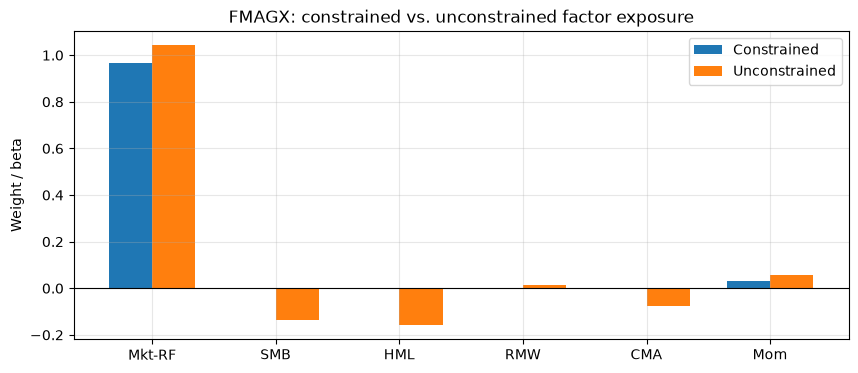

In [5]:
fig, ax = plt.subplots()
x = np.arange(len(comparison))
width = 0.35
ax.bar(x - width / 2, comparison["constrained_weight"], width, label="Constrained")
ax.bar(x + width / 2, comparison["unconstrained_beta"], width, label="Unconstrained")
ax.set_xticks(x)
ax.set_xticklabels(comparison.index)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Weight / beta")
ax.set_title(f"{FUND_TICKER}: constrained vs. unconstrained factor exposure")
ax.legend()
plt.show()

**Reading this chart**: every factor where the constrained model shows exactly
0 while the unconstrained model shows something clearly negative (`SMB`,
`HML`, `CMA` here) is a case where the simplex constraint is *hiding* a real,
economically meaningful negative tilt -- not just adding noise. See
`LIMITATIONS.md` for why Sharpe's simplex constraint, built for long-only
asset-class indices, is a stylized adaptation when applied to the
Fama-French/Carhart long-short factors used here.

## 3. Time-varying exposure: rolling OLS vs. Kalman filter

A single whole-sample beta hides how exposure moves through time. We compare
two estimators of the same time-varying model:

- **Rolling-window OLS**: refit on the trailing window at every date. Simple,
  but reacts to a real shift only gradually (up to a full window's lag), and
  drops old observations abruptly once they exit the window ("ghosting").
- **Kalman filter**: factor betas follow a random walk; the process-noise
  covariance uses the discount-factor trick from Bayesian dynamic linear
  models (West & Harrison, 1997), so `delta` has a scale-free half-life
  interpretation (`half_life_days = ln(0.5) / ln(1 - delta)`).

**Calibration note**: the first default tried for `delta` (`1e-4`, a
~19-year half-life) made the filter essentially frozen. `config.KALMAN_DELTA
= 0.02` (~34-day half-life) was chosen empirically by checking which value
made the filter visibly lead the rolling window around a real, dateable
event -- the Feb-Apr 2020 COVID crash -- shown below.

2026-09-18 12:52:31,501 INFO src.kalman_beta: Rolling OLS (window=126): first 125 observations have no estimate (insufficient history for a full window).


2026-09-18 12:52:31,502 INFO src.kalman_beta: Kalman filter warm-up: 126 observations used to seed initial state (estimated observation variance R=1.123e-06); no estimate reported for this period.


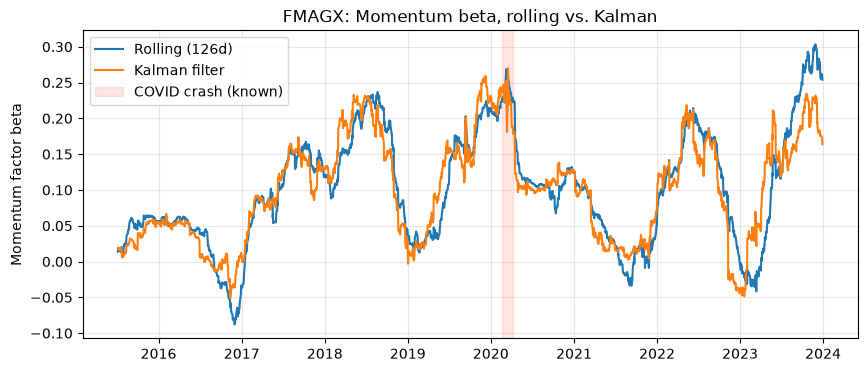

In [6]:
rolling = rolling_ols_betas(dataset.excess_returns, dataset.factor_returns, window=126)
kalman = kalman_filter_betas(dataset.excess_returns, dataset.factor_returns)  # delta from config

fig, ax = plt.subplots()
ax.plot(rolling.betas.index, rolling.betas["Mom"], label="Rolling (126d)")
ax.plot(kalman.betas.index, kalman.betas["Mom"], label="Kalman filter")
ax.axvspan(pd.Timestamp("2020-02-19"), pd.Timestamp("2020-04-07"), color="red", alpha=0.1, label="COVID crash (known)")
ax.set_ylabel("Momentum factor beta")
ax.set_title(f"{FUND_TICKER}: Momentum beta, rolling vs. Kalman")
ax.legend()
plt.show()

In [7]:
lag_table = compare_lag_around_date(rolling, kalman, pd.Timestamp("2020-03-23"), factor="Mom", window_days=45)
print("Beta path around the COVID crash (every 5th trading day):")
lag_table.iloc[::5]

Beta path around the COVID crash (every 5th trading day):


,rolling,kalman
Date,,
2020-02-07,0.216482,0.239907
2020-02-14,0.222760,0.240878
2020-02-24,0.226787,0.242698
2020-03-02,0.221897,0.222998
2020-03-09,0.268692,0.251702
2020-03-16,0.249496,0.269800
2020-03-23,0.242406,0.226807
2020-03-30,0.235185,0.222094
2020-04-06,0.228390,0.186714


By late April 2020, the Kalman estimate has already dropped closer to its
post-crash level than the 126-day rolling estimate, which is still catching
up -- a direct, dateable demonstration of reduced lag, not just a visually
smoother line.

## 4. Regime detection: Gaussian HMM on SPY + VIX

A 2-state Gaussian HMM (`hmmlearn`) fit on **market-wide** signals only (SPY
returns, VIX level) -- deliberately never on the target fund's own returns,
since that would make every downstream regime-conditional number circular.
`hmmlearn` assigns state indices arbitrarily, so states are relabeled after
fitting by ascending volatility-feature mean.

Two standard HMM assumptions worth naming: the **Markov property** (regime
persistence is entirely a function of the fitted transition matrix, no
richer memory), and **Gaussian, state-conditional-i.i.d. emissions** (daily
equity returns are known to have fatter tails than this implies).

**Validation**: check the fitted regimes against known historical stress
windows -- used only as a post-fit sanity check, never as fitting input
(that would be circular).

In [8]:
spy_prices = loader.get_prices(config.REGIME_MARKET_PROXY, START, END)
spy_returns = loader.to_log_returns(spy_prices)[config.REGIME_MARKET_PROXY]
vix = loader.get_vix(START, END)

regime_result = fit_regime_hmm(spy_returns, vix=vix, n_regimes=2)
print("State means (original units):")
print(regime_result.state_means)
print()
validate_against_known_stress_periods(regime_result)

2026-09-18 12:52:31,624 INFO src.data_loader: Loaded prices_SPY_2015-01-01_2024-01-01 from cache (0.5 days old).


2026-09-18 12:52:31,626 INFO src.data_loader: Loaded prices_^VIX_2015-01-01_2024-01-01 from cache (0.0 days old).


2026-09-18 12:52:31,628 WARNING src.regime_detection: Dropped 1 rows with missing regime features (source=vix).


2026-09-18 12:52:31,771 INFO src.regime_detection: Fit 2-regime HMM on 2263 observations (vol_source=vix). Regime frequencies: {'calm': 1332, 'stressed': 931}


State means (original units):
            return  vol_signal
calm      0.000916   14.006920
stressed -0.000218   24.916251



,start,end,n_days,pct_stressed
period,,,,
COVID crash,2020-02-19,2020-04-07,35,0.914286
2022 rate-hike selloff,2022-01-03,2022-10-14,198,0.989899


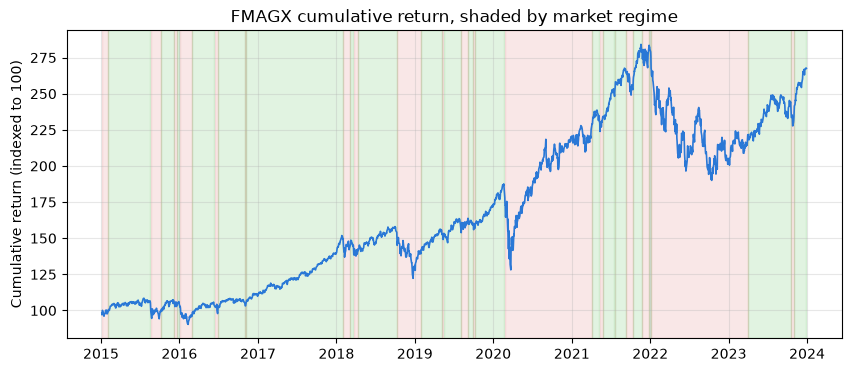

In [9]:
cumulative_return = np.exp(dataset.fund_returns.cumsum()) * 100
episodes = regime_episodes(regime_result.regime_labels)

fig, ax = plt.subplots()
colors = {"calm": "#0ca30c", "stressed": "#d03b3b"}
for _, ep in episodes.iterrows():
    ax.axvspan(ep["start"], ep["end"], color=colors.get(ep["label"], "gray"), alpha=0.12)
ax.plot(cumulative_return.index, cumulative_return, color="#2a78d6", linewidth=1.2)
ax.set_ylabel("Cumulative return (indexed to 100)")
ax.set_title(f"{FUND_TICKER} cumulative return, shaded by market regime")
plt.show()

## 5. Regime-conditional risk attribution

Within each regime (plus "overall" as a baseline): historical (empirical
-quantile, not parametric) VaR(95%)/CVaR(95%) of the fund's actual returns,
factor betas and R^2 refit on that regime's observations, and a per-factor
Euler variance decomposition (`beta_j * (Sigma_f @ beta)_j`) that sums
exactly to the factor-driven share of total variance.

In [10]:
risk_metrics = compute_regime_risk_metrics(
    dataset.fund_returns, dataset.excess_returns, dataset.factor_returns, regime_result.regime_labels
)
regime_comparison_table(risk_metrics)

,n_obs,annualized_vol,annualized_mean_return,VaR_95,CVaR_95,R_squared,idiosyncratic_variance_share,beta_Mkt-RF,beta_SMB,beta_HML,beta_RMW,beta_CMA,beta_Mom
overall,2263.0,0.200811,0.109597,0.019134,0.030905,0.969059,0.030941,1.044015,-0.137560,-0.157367,0.012572,-0.078179,0.058700
calm,1332.0,0.105786,0.251464,0.010289,0.014432,0.909641,0.090359,1.046640,-0.128096,-0.137079,-0.040878,-0.013946,0.079559
stressed,931.0,0.285985,-0.093374,0.029257,0.041467,0.981780,0.018220,1.039576,-0.149204,-0.167037,0.061020,-0.121681,0.052890


**The finding that motivates this whole project**: `Mkt-RF` beta barely
moves between regimes, but idiosyncratic variance share collapses in the
stressed regime -- the fund's *market* exposure is stable, but its
*diversification* quietly disappears exactly when it matters most. A
whole-sample static style analysis (section 2) would never surface this.

## 6. Style Drift Score

Distance (cosine or Euclidean) between the fund's current exposure vector
and a baseline -- its own first 12 months by default, or a stated-mandate
vector. A drift event is flagged when the score exceeds
`baseline-period mean + 2*std`, calibrated to each fund's own baseline-period
noise.

2026-09-18 12:52:31,911 INFO src.drift_score: Dropped 125 rows with missing exposure data before computing drift (e.g. rolling/Kalman burn-in period).


2026-09-18 12:52:31,932 INFO src.drift_score: Style drift (cosine): threshold=0.0043 (baseline mean=0.0016, std=0.0014); 7 flagged episode(s).


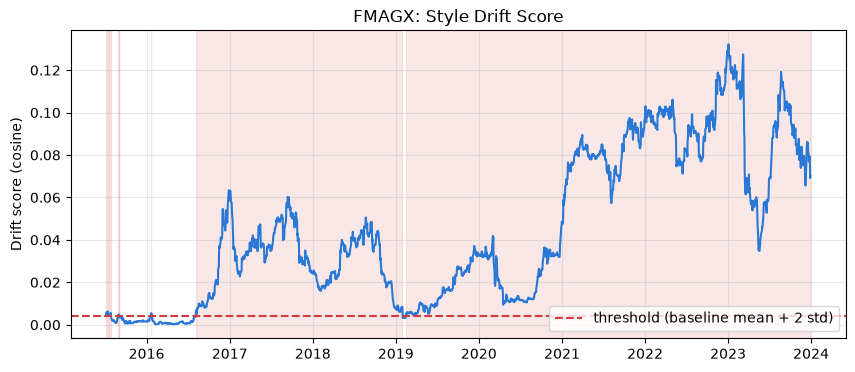

,start,end,peak_date,peak_drift
0,2015-07-07,2015-07-17,2015-07-15,0.006271
1,2015-07-22,2015-07-27,2015-07-27,0.005583
2,2015-08-28,2015-08-31,2015-08-28,0.004556
3,2015-09-02,2015-09-02,2015-09-02,0.004864
4,2016-01-21,2016-01-22,2016-01-22,0.005520
5,2016-08-05,2019-01-30,2016-12-28,0.063398
6,2019-02-15,2023-12-29,2023-01-03,0.132132


In [11]:
drift = compute_style_drift(rolling.betas, metric="cosine")

fig, ax = plt.subplots()
for _, ev in drift.flagged_events.iterrows():
    ax.axvspan(ev["start"], ev["end"], color="#d03b3b", alpha=0.12)
ax.plot(drift.drift.index, drift.drift, color="#2a78d6")
ax.axhline(drift.threshold, color="#d03b3b", linestyle="--", label="threshold (baseline mean + 2 std)")
ax.set_ylabel("Drift score (cosine)")
ax.set_title(f"{FUND_TICKER}: Style Drift Score")
ax.legend()
plt.show()

drift.flagged_events

## 7. Crowding Score (stretch goal)

For a peer group of similarly-categorized funds/ETFs, fit each one's own
rolling-OLS exposure vector, then average pairwise cosine *similarity*
across the group at each date -- a high score means the group's managers are
converging on the same factor tilts.

2026-09-18 12:52:32,018 INFO src.data_loader: Loaded prices_FCNTX_2015-01-01_2024-01-01 from cache (0.5 days old).


2026-09-18 12:52:32,020 INFO src.data_loader: Loaded ff_F-F_Research_Data_5_Factors_2x3_daily_2015-01-01_2024-01-01 from cache (0.5 days old).


2026-09-18 12:52:32,022 INFO src.data_loader: Loaded ff_F-F_Momentum_Factor_daily_2015-01-01_2024-01-01 from cache (0.5 days old).


2026-09-18 12:52:32,025 WARNING src.data_loader: Dropped 1 rows (of 2264) with missing data while aligning 'FCNTX' with factor data. Date range affected: 2015-01-02 to 2015-01-02.


2026-09-18 12:52:32,081 INFO src.kalman_beta: Rolling OLS (window=126): first 125 observations have no estimate (insufficient history for a full window).


...

2026-09-18 12:52:32,211 INFO src.data_loader: Loaded ff_F-F_Research_Data_5_Factors_2x3_daily_2015-01-01_2024-01-01 from cache (0.5 days old).


2026-09-18 12:52:32,213 INFO src.data_loader: Loaded ff_F-F_Momentum_Factor_daily_2015-01-01_2024-01-01 from cache (0.5 days old).


2026-09-18 12:52:32,217 WARNING src.data_loader: Dropped 1 rows (of 2264) with missing data while aligning 'VUG' with factor data. Date range affected: 2015-01-02 to 2015-01-02.


2026-09-18 12:52:32,272 INFO src.kalman_beta: Rolling OLS (window=126): first 125 observations have no estimate (insufficient history for a full window).


2026-09-18 12:52:32,992 INFO src.drift_score: Crowding score computed over 2138 dates for 4 peers (median peers/date: 4).


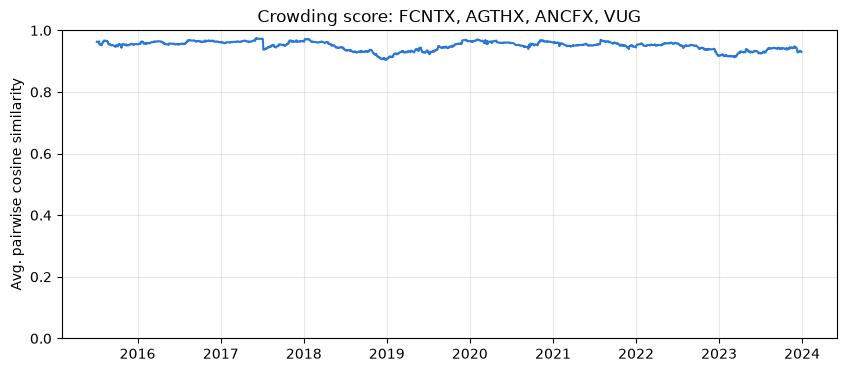

Mean crowding: 0.950  (range 0.904-0.974)


In [12]:
peer_betas, skipped = build_peer_exposure_vectors(loader, config.DEFAULT_PEER_GROUP, START, END)
if skipped:
    print(f"Skipped peers (couldn't fetch): {skipped}")

crowding = compute_crowding_score(peer_betas, skipped_tickers=skipped)

fig, ax = plt.subplots()
ax.plot(crowding.crowding.index, crowding.crowding, color="#2a78d6")
ax.set_ylim(0, 1)
ax.set_ylabel("Avg. pairwise cosine similarity")
ax.set_title(f"Crowding score: {', '.join(crowding.peer_tickers)}")
plt.show()

print(f"Mean crowding: {crowding.crowding.mean():.3f}  "
      f"(range {crowding.crowding.min():.3f}-{crowding.crowding.max():.3f})")

## Summary

This walkthrough validated every modeling choice against either a known
ground truth (SPY's near-100% `Mkt-RF` loading) or a known historical event
(the COVID crash, the 2022 rate-hike selloff), rather than asserting each
method works. See `README.md` for the full write-up of each phase and
`LIMITATIONS.md` for what none of these methods can tell you -- most
importantly, that everything here is inferred from returns alone and can't
see intra-period trading, hedges, or leverage changes that unwind before
the return series is observed.